# Titanic ML

## Importations

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

## Chargement des données

In [ ]:
df = pd.read_csv("data/titanic.csv")
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## Intégrité des données

In [54]:
print("=== Total ===")
print(f"{len(df)} rows\n")

# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({"missing": missing, "percent": missing_pct})
print("=== Missing Values ===")
print(missing_report[missing_report["missing"] > 0])

# Duplicate rows
n_duplicates = df.duplicated().sum()
print(f"\n=== Duplicate Rows ===")
print(f"{n_duplicates} duplicate row(s) found")

# Drop duplicates
df.drop_duplicates(inplace=True)

=== Total ===
891 rows

=== Missing Values ===
             missing  percent
age              177     19.9
embarked           2      0.2
deck             688     77.2
embark_town        2      0.2

=== Duplicate Rows ===
107 duplicate row(s) found


## Taux de survie par sexe

On regroupe les passagers par sexe et on calcule la moyenne de la colonne `survived` (0 = n'a pas survécu, 1 = a survécu), ce qui donne le taux de survie pour chaque groupe.

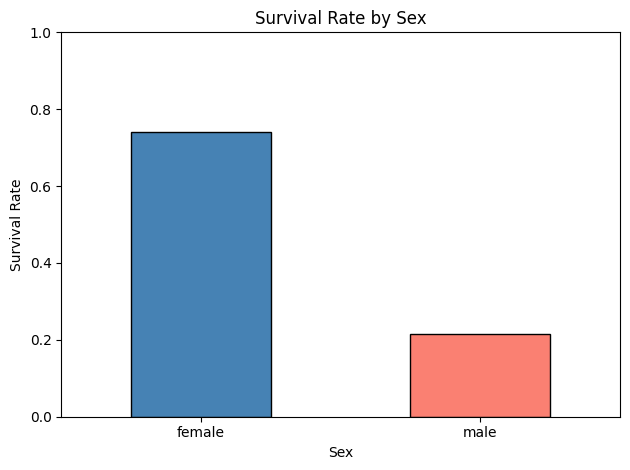

In [55]:
survival_by_sex = df.groupby("sex")["survived"].mean()

survival_by_sex.plot(kind="bar", color=["steelblue", "salmon"], edgecolor="black")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Sex")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Taux de survie par tranche d'âge

On répartit les âges des passagers en 5 groupes (enfants, adolescents, jeunes adultes, adultes d'âge moyen, personnes âgées) à l'aide de `pd.cut`, puis on calcule le taux de survie moyen par groupe. Les passagers dont l'âge est manquant sont exclus automatiquement.

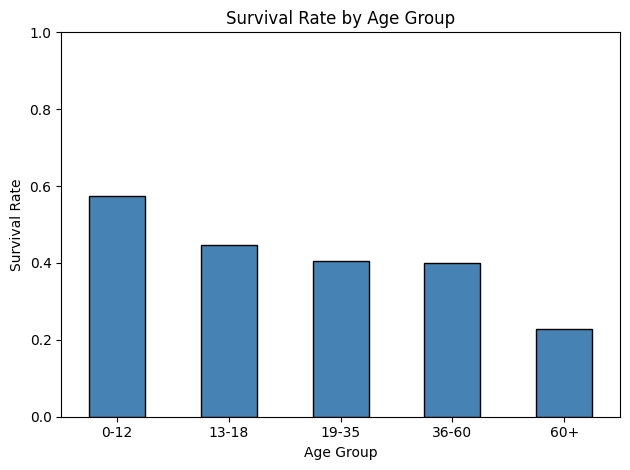

In [56]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["0-12", "13-18", "19-35", "36-60", "60+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

survival_by_age = df.groupby("age_group", observed=True)["survived"].mean()

survival_by_age.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Taux de survie par classe

On regroupe les passagers par classe de billet (`pclass` : 1 = Première, 2 = Deuxième, 3 = Troisième) et on calcule le taux de survie moyen. Les classes supérieures avaient un meilleur accès aux canots de sauvetage, on s'attend donc à un gradient clair.

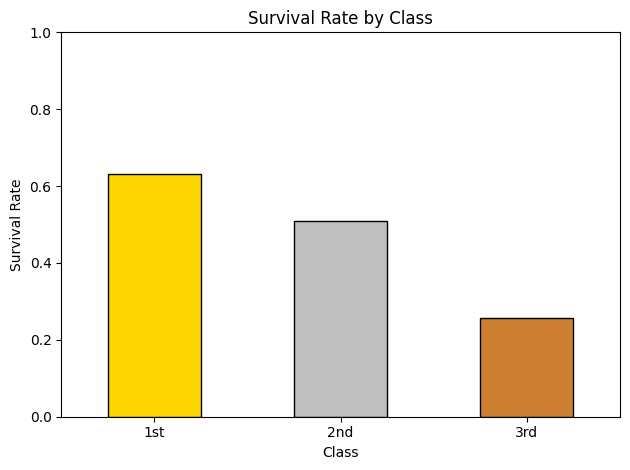

In [57]:
survival_by_class = df.groupby("pclass")["survived"].mean()

survival_by_class.plot(kind="bar", color=["gold", "silver", "#cd7f32"], edgecolor="black")
plt.title("Survival Rate by Class")
plt.ylabel("Survival Rate")
plt.xlabel("Class")
plt.xticks([0, 1, 2], ["1st", "2nd", "3rd"], rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()